# Radiology Report Features (Text & Clinical)  
**Jupyter Notebook Section for Group Project**  

**Author:** Liao Wang and Jun
**Date:** 2026-04-17  

## Phase 1: Data Alignment and Preprocessing Pipeline

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


def load_preprocessed_pkl(train_path, val_path, test_path, target_col='label'):
    df_train_raw = pd.read_pickle(train_path)
    df_val_raw = pd.read_pickle(val_path)
    df_test_raw = pd.read_pickle(test_path)

    print(f"Columns found in PKL: {df_train_raw.columns.tolist()[:5]}...")

    if target_col not in df_train_raw.columns:
        possible_target = df_train_raw.columns[0]
        print(
            f"Warning: '{target_col}' not found. Using '{possible_target}' as target.")
        target_col = possible_target

    df_train = pd.concat([df_train_raw, df_val_raw],
                         axis=0).reset_index(drop=True)

    y_train_raw = df_train[target_col]
    X_train = df_train.drop(columns=[target_col])

    X_test = df_test_raw.drop(
        columns=[target_col]) if target_col in df_test_raw.columns else df_test_raw.copy()

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train_raw.astype(str))

    common_cols = list(set(X_train.columns) & set(X_test.columns))
    X_train = X_train[common_cols].apply(
        pd.to_numeric, errors='coerce').fillna(0)
    X_test = X_test[common_cols].apply(
        pd.to_numeric, errors='coerce').fillna(0)

    return X_train, y_train, X_test, common_cols, label_encoder

## Phase 2: Advanced Feature Engineering

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold


def optimize_features(X_train, X_test, correlation_threshold=0.85):
    vt = VarianceThreshold(threshold=0.01)
    X_train_vt = vt.fit_transform(X_train)
    X_test_vt = vt.transform(X_test)

    retained_features = X_train.columns[vt.get_support()].tolist()

    X_train_df = pd.DataFrame(X_train_vt, columns=retained_features)
    X_test_df = pd.DataFrame(X_test_vt, columns=retained_features)

    corr_matrix = X_train_df.corr().abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    features_to_drop = [col for col in upper_triangle.columns if any(
        upper_triangle[col] > correlation_threshold)]
    final_features = [
        feat for feat in retained_features if feat not in features_to_drop]

    X_train_opt = X_train_df[final_features]
    X_test_opt = X_test_df[final_features]

    return X_train_opt, X_test_opt, final_features

## Phase 3: Cross-Validation & Baseline Construction

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score


def run_baseline_cv(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    results = {
        'LR_acc': [], 'LR_f1': [],
        'RF_acc': [], 'RF_f1': []
    }

    models = {
        'LR': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        'RF': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    }

    X_arr = X.values if isinstance(X, pd.DataFrame) else X
    y_arr = y.values if isinstance(y, pd.Series) else y

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_tr, y_tr = X_arr[train_idx], y_arr[train_idx]
        X_va, y_va = X_arr[val_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_va_scaled = scaler.transform(X_va)

        lr = models['LR']
        lr.fit(X_tr_scaled, y_tr)
        lr_preds = lr.predict(X_va_scaled)
        results['LR_acc'].append(accuracy_score(y_va, lr_preds))
        results['LR_f1'].append(f1_score(y_va, lr_preds, average='macro'))

        rf = models['RF']
        rf.fit(X_tr, y_tr)
        rf_preds = rf.predict(X_va)
        results['RF_acc'].append(accuracy_score(y_va, rf_preds))
        results['RF_f1'].append(f1_score(y_va, rf_preds, average='macro'))

    print(
        f"Logistic Regression - Accuracy: {np.mean(results['LR_acc']):.4f} ± {np.std(results['LR_acc']):.4f}")
    print(
        f"Logistic Regression - F1 Macro: {np.mean(results['LR_f1']):.4f} ± {np.std(results['LR_f1']):.4f}")
    print(
        f"Random Forest       - Accuracy: {np.mean(results['RF_acc']):.4f} ± {np.std(results['RF_acc']):.4f}")
    print(
        f"Random Forest       - F1 Macro: {np.mean(results['RF_f1']):.4f} ± {np.std(results['RF_f1']):.4f}")

    return results

## Phase 4: Hyperparameter Tuning (LightGBM & Optuna)

In [3]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score


def optimize_lgbm(X, y, n_trials=50, n_splits=5):
    X_arr = X.values if isinstance(X, pd.DataFrame) else X
    y_arr = y.values if isinstance(y, pd.Series) else y
    n_classes = len(np.unique(y_arr))

    def objective(trial):
        params = {
            'objective': 'multiclass',
            'num_class': n_classes,
            'metric': 'multi_logloss',
            'boosting_type': 'gbdt',
            'random_state': 42,
            'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'subsample': trial.suggest_float('subsample', 0.4, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'class_weight': 'balanced',
            'verbose': -1
        }

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for train_idx, val_idx in skf.split(X_arr, y_arr):
            X_tr, y_tr = X_arr[train_idx], y_arr[train_idx]
            X_va, y_va = X_arr[val_idx], y_arr[val_idx]

            model = lgb.LGBMClassifier(**params)

            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(
                    stopping_rounds=30, verbose=False)]
            )

            preds = model.predict(X_va)
            score = f1_score(y_va, preds, average='macro')
            cv_scores.append(score)

        return np.mean(cv_scores)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    print(f"Best CV Macro F1 Score: {study.best_value:.4f}")
    print("Best Parameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    return study.best_params


def train_final_model(X_train, y_train, best_params):
    n_classes = len(np.unique(y_train))

    final_params = best_params.copy()
    final_params.update({
        'objective': 'multiclass',
        'num_class': n_classes,
        'class_weight': 'balanced',
        'random_state': 42,
        'n_estimators': 500,
        'verbose': -1
    })

    final_model = lgb.LGBMClassifier(**final_params)
    final_model.fit(X_train, y_train)

    return final_model

c:\Users\LIAO WANG\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Phase 5: Interpretation and Exporting Probabilities for Global Ensemble

In [24]:
def export_probabilities_for_voting(X_train, y_train, X_test, lgb_params, rf_params, xgb_params, label_encoder):
    import xgboost as xgb
    import lightgbm as lgb
    from sklearn.ensemble import VotingClassifier, RandomForestClassifier

    # We need to format params for the estimators
    estimators = [
        ('lgb', lgb.LGBMClassifier(**lgb_params)),
        ('rf', RandomForestClassifier(**rf_params)),
        ('xgb', xgb.XGBClassifier(**xgb_params))
    ]

    tabular_ensemble = VotingClassifier(
        estimators=estimators,
        voting='soft',
        n_jobs=-1
    )

    tabular_ensemble.fit(X_train, y_train)

    test_probas = tabular_ensemble.predict_proba(X_test)
    class_names = label_encoder.classes_

    prob_columns = [f"prob_{cls}" for cls in class_names]
    probas_df = pd.DataFrame(test_probas, columns=prob_columns)

    # Adding an Id column for easier merging with group members
    probas_df.insert(0, 'Id', np.arange(len(test_probas)))

    probas_df.to_csv('tabular_features_predict_proba.csv', index=False)

    return tabular_ensemble, probas_df

## Main

Columns found in PKL: ['Overall_class', 'location', 'flag', 'Sex_y', 'Age_y']...
Starting Baseline Evaluation...


c:\Users\LIAO WANG\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\LIAO WANG\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    h

LR F1: 0.4733 | RF F1: 0.6884
Starting LightGBM Hyperparameter Tuning...


[I 2026-04-22 20:09:04,800] Trial 0 finished with value: 0.7430440139444737 and parameters: {'learning_rate': 0.06739629989636868, 'max_depth': 11, 'num_leaves': 105, 'reg_alpha': 0.013246876078109204, 'reg_lambda': 0.0026895294431748488}. Best is trial 0 with value: 0.7430440139444737.
[I 2026-04-22 20:09:09,760] Trial 1 finished with value: 0.6808272035313404 and parameters: {'learning_rate': 0.04985073101384126, 'max_depth': 6, 'num_leaves': 97, 'reg_alpha': 0.015137388729548317, 'reg_lambda': 3.880719215746327}. Best is trial 0 with value: 0.7430440139444737.
[I 2026-04-22 20:09:19,231] Trial 2 finished with value: 0.71319502257769 and parameters: {'learning_rate': 0.02547843869557745, 'max_depth': 11, 'num_leaves': 109, 'reg_alpha': 0.06001794576736737, 'reg_lambda': 0.16898216890926585}. Best is trial 0 with value: 0.7430440139444737.
[I 2026-04-22 20:09:23,301] Trial 3 finished with value: 0.6707065648858046 and parameters: {'learning_rate': 0.06111561416533397, 'max_depth': 5, 

Generating Model Interpretability Plots...


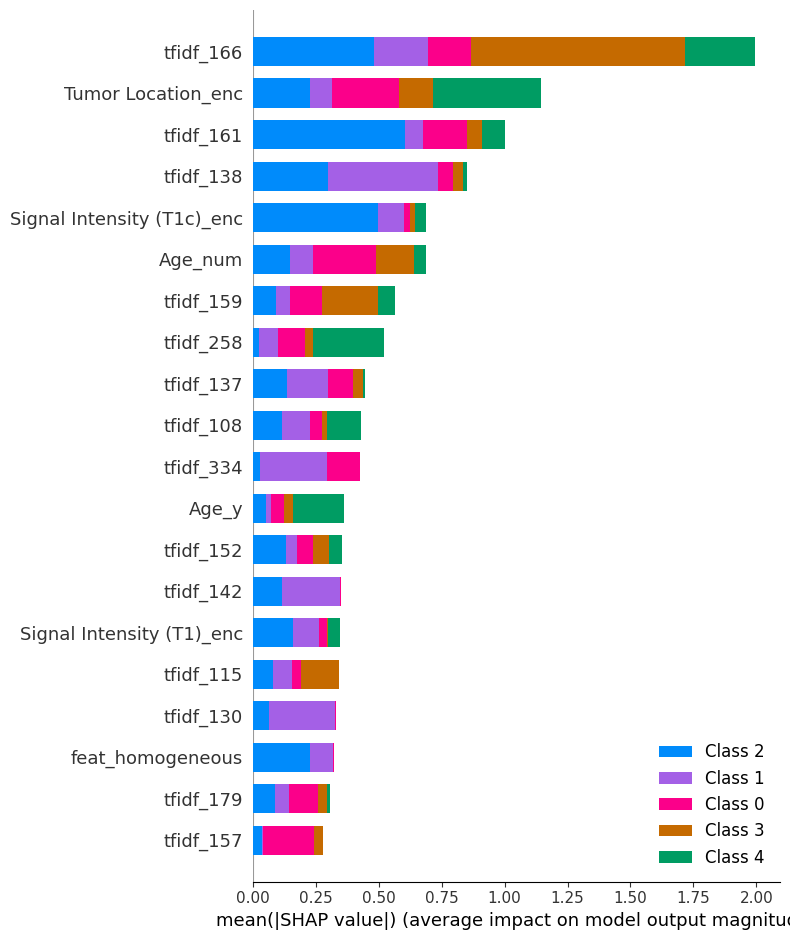

Training Ensemble and Exporting Probabilities...
Process completed. Output saved to 'tabular_features_predict_proba.csv'.


In [25]:
import os

train_pkl = os.path.join('processed_features', 'train_text_clinical.pkl')
val_pkl = os.path.join('processed_features', 'val_text_clinical.pkl')
test_pkl = os.path.join('processed_features', 'test_text_clinical.pkl')

X_train, y_train, X_test, feature_names, le = load_preprocessed_pkl(
    train_pkl, val_pkl, test_pkl
)

X_train_opt, X_test_opt, final_features = optimize_features(X_train, X_test)

print("Starting Baseline Evaluation...")
run_baseline_cv(X_train_opt, y_train)

print("Starting LightGBM Hyperparameter Tuning...")
lgbm_best_params = optimize_lgbm(X_train_opt, y_train, n_trials=10)

final_model = train_final_model(X_train_opt, y_train, lgbm_best_params)

print("Generating Model Interpretability Plots...")
interpret_with_shap(final_model, X_train_opt)

rf_params = {'n_estimators': 100,
             'class_weight': 'balanced', 'random_state': 42}
xgb_params = {'n_estimators': 100, 'learning_rate': 0.1,
              'max_depth': 6, 'random_state': 42}

print("Training Ensemble and Exporting Probabilities...")
tabular_ensemble, prob_df = export_probabilities_for_voting(
    X_train_opt,
    y_train,
    X_test_opt,
    lgbm_best_params,
    rf_params,
    xgb_params,
    le
)

print("Process completed. Output saved to 'tabular_features_predict_proba.csv'.")